## **Weekly News Summarization**

#### Installing and Importing the necessary libraries

In [ ]:
# Installation for GPU llama-cpp-python
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 178.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 216.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 254.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 168.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
!pip install huggingface_hub==0.23.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 15.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.23.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.2 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.23.2 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.2 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.2 which is incompatible.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
stock_news = pd.read_csv("/content/drive/MyDrive/MLProjects/StockAnalysis/stock_news.csv") #Complete the code to load the dataset

In [ ]:
data = stock_news.copy()

#### Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"


model_path = hf_hub_download(
    repo_id=model_name_or_path, # Complete the code to mention the repo_id
    filename=model_basename # Complete the code to mention the filename
)

mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [ ]:
# uncomment and run the following code in case GPU is not being used

# llm = Llama(
#     model_path=model_path,
#     n_ctx=4500, # Context window
#     n_cores=-2 # Number of CPU cores to use
# )

#### Aggregating the data weekly

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
# Aggregate the grouped data on a weekly basis:
# concatenate 'content' values into a single string separated by ' || '.
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=4000, #Complete the code to set the maximum number of tokens the model should generate for this task.
      temperature=0.7, #Complete the code to set the value for temperature.
      top_p=0.9, #Complete the code to set the value for top_p
      top_k=50, #Complete the code to set the value for top_k
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

In [ ]:
news = data_1.loc[0, 'News']

In [ ]:
print(len(news.split(' ')))
news

2611


' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

In [ ]:
prompt = """
    You are an expert data analyst specializing in news content analysis.

    Task: Summarize the provided news articles for the week by identifying the top three positive and top three negative events that are most likely to impact the stock price.

    Instructions:
    1. Read the news articles carefully.
    2. Identify events that could positively or negatively impact stock prices.
    3. Select the top three most significant positive events.
    4. Select the top three most significant negative events.
    5. Ensure the summary is concise and highlights key aspects of each event.
    6. If there are fewer than three positive or negative events, list all available events.
    7. If there are no positive or negative events, state 'No significant positive events' or 'No significant negative events' respectively.

    Return the output in JSON format with two keys: "Positive Events" and "Negative Events". Each key should contain a list of strings, where each string is a summary of an event.

    Example Output:
    {
      "Positive Events": [
        "Summary of positive event 1",
        "Summary of positive event 2",
        "Summary of positive event 3"
      ],
      "Negative Events": [
        "Summary of negative event 1",
        "Summary of negative event 2",
        "Summary of negative event 3"
      ]
    }
    """

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=4000, # Max tokens for the generated response
      temperature=0.7, # Controls randomness: higher values mean more random output
      top_p=0.9, # Nucleus sampling: only considers tokens with cumulative probability above p
      top_k=50, # Top-k sampling: considers only the top k most likely next tokens
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

In [ ]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

 {
         "Positive Events": [
           "Roku Inc announced plans to offer premium video channels on a subscription basis through its free streaming service, The Roku Channel.",
           "The Supreme Court will review Broadcom's appeal in a shareholder lawsuit over the 2015 acquisition of Emulex.",
           "The Chinese central bank announced a fifth reduction in the required reserve ratio (RRR) for banks, freeing up approximately 116.5 billion yuan for new lending."
         ],
         "Negative Events": [
           "Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales.",
           "Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades.",
           "Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency."
     

##### Checking the model output on the weekly data

In [ ]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

100%|██████████| 18/18 [05:06<00:00, 17.02s/it]

CPU times: user 4min 35s, sys: 29.1 s, total: 5min 4s
Wall time: 5min 6s


In [ ]:
data_1["Key Events"].head() #Complete the code to print the first 5 rows of the 'Key_Events' column

,Key Events
0,"{\n ""Positive Events"": [\n ..."
1,"{\n ""Positive Events"": [\n ..."
2,"{\n ""Positive Events"": [\n ""A..."
3,"{\n ""Positive Events"": [\n ..."
4,"{\n ""Positive Events"": [\n ..."


##### Formatting the model output

In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"{\n ""Positive Events"": [\n ...",{'Positive Events': ['Roku Inc announced plans...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"{\n ""Positive Events"": [\n ...",{'Positive Events': ['Sprint and Samsung plan ...
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""Positive Events"": [\n ""A...",{'Positive Events': ['Apple CEO Tim Cook annou...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""Positive Events"": [\n ...",{'Positive Events': ['SNB governor Andrea Maec...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""Positive Events"": [\n ...",{'Positive Events': ['Apple reported stronger-...


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,Positive Events,Negative Events
0,[Roku Inc announced plans to offer premium vid...,[Apple lowered its fiscal Q1 revenue guidance ...
1,[Sprint and Samsung plan to release 5G smartph...,[Geely forecasts flat sales for 2019 due to ec...
2,[Apple CEO Tim Cook announced internal staffin...,[Concerns over global economic slowdown intens...
3,[SNB governor Andrea Maechler emphasized the i...,[White House economic adviser Lawrence Kudlow ...
4,[Apple reported stronger-than-expected earning...,[Caterpillar Inc reported lower-than-expected ...


In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
final_output.columns = ['Week End Date', 'News', 'Week Positive Events', 'Week Negative Events']

final_output.head()

,Week End Date,News,Week Positive Events,Week Negative Events
0,2019-01-06,The tech sector experienced a significant dec...,[Roku Inc announced plans to offer premium vid...,[Apple lowered its fiscal Q1 revenue guidance ...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,[Sprint and Samsung plan to release 5G smartph...,[Geely forecasts flat sales for 2019 due to ec...
2,2019-01-20,The U.S. stock market declined on Monday as c...,[Apple CEO Tim Cook announced internal staffin...,[Concerns over global economic slowdown intens...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",[SNB governor Andrea Maechler emphasized the i...,[White House economic adviser Lawrence Kudlow ...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,[Apple reported stronger-than-expected earning...,[Caterpillar Inc reported lower-than-expected ...


In [ ]:
def calculate_sentiment_score(row):
    positive_count = len(row['Week Positive Events'])
    negative_count = len(row['Week Negative Events'])
    return positive_count - negative_count

final_output['Sentiment Score'] = final_output.apply(calculate_sentiment_score, axis=1)
final_output.head()

,Week End Date,News,Week Positive Events,Week Negative Events,Sentiment Score
0,2019-01-06,The tech sector experienced a significant dec...,[Roku Inc announced plans to offer premium vid...,[Apple lowered its fiscal Q1 revenue guidance ...,0
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,[Sprint and Samsung plan to release 5G smartph...,[Geely forecasts flat sales in 2019 due to eco...,0
2,2019-01-20,The U.S. stock market declined on Monday as c...,[Apple CEO Tim Cook announced internal staffin...,[The U.S. stock market declined on Monday due ...,0
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",[Swiss National Bank governor Andrea Maechler ...,"[The Dow, S&P 500, and Nasdaq experienced sign...",0
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,[Apple reported higher-than-expected Q4 earnin...,[Caterpillar reported lower-than-expected Q4 e...,0


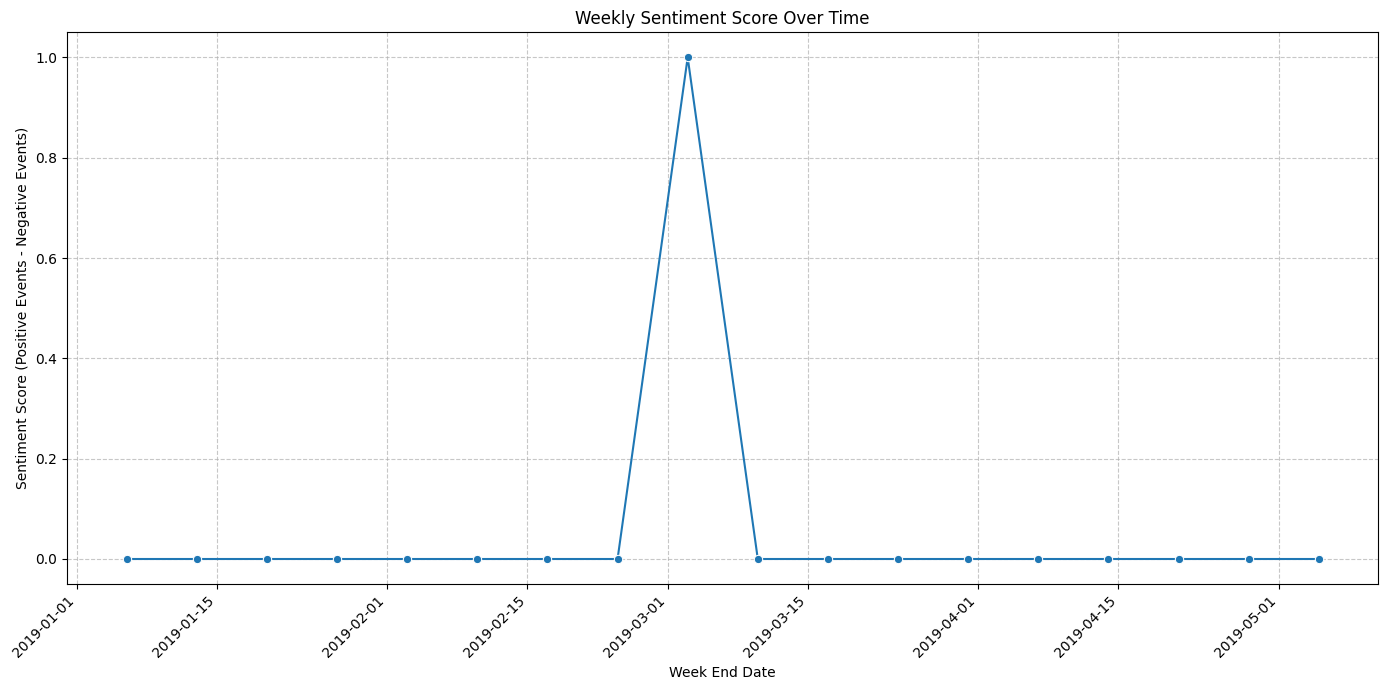

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the function to calculate sentiment score (ensure it's available)
def calculate_sentiment_score(row):
    # Using .get() with default empty list to safely handle potential missing columns
    positive_events = row.get('Week Positive Events', [])
    negative_events = row.get('Week Negative Events', [])
    # Ensure the values are list-like before calling len()
    positive_count = len(positive_events) if isinstance(positive_events, list) else 0
    negative_count = len(negative_events) if isinstance(negative_events, list) else 0
    return positive_count - negative_count

# Re-calculate 'Sentiment Score' to ensure it's present and up-to-date in final_output
final_output['Sentiment Score'] = final_output.apply(calculate_sentiment_score, axis=1)

# Visualize Sentiment Trends
plt.figure(figsize=(14, 7))
sns.lineplot(x='Week End Date', y='Sentiment Score', data=final_output, marker='o')
plt.title('Weekly Sentiment Score Over Time')
plt.xlabel('Week End Date')
plt.ylabel('Sentiment Score (Positive Events - Negative Events)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Ensure 'Date' column in original data is datetime
data['Date'] = pd.to_datetime(data['Date'])

# Group original data by week and calculate the mean 'Close' price for each week
weekly_close_price = data.groupby(pd.Grouper(key='Date', freq='W'))['Close'].mean().reset_index()
weekly_close_price.rename(columns={'Date': 'Week End Date', 'Close': 'Weekly Avg Close Price'}, inplace=True)

# Merge the weekly average close prices with the final_output DataFrame
final_output_with_price = pd.merge(final_output, weekly_close_price, on='Week End Date', how='left')

# Display the head of the merged DataFrame
display(final_output_with_price.head())

,Week End Date,News,Week Positive Events,Week Negative Events,Sentiment Score,Weekly Avg Close Price
0,2019-01-06,The tech sector experienced a significant dec...,[Roku Inc announced plans to offer premium vid...,[Apple lowered its fiscal Q1 revenue guidance ...,0,42.631387
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,[Sprint and Samsung plan to release 5G smartph...,[Geely forecasts flat sales for 2019 due to ec...,0,53.329597
2,2019-01-20,The U.S. stock market declined on Monday as c...,[Apple CEO Tim Cook announced internal staffin...,[Concerns over global economic slowdown intens...,0,37.066473
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",[SNB governor Andrea Maechler emphasized the i...,[White House economic adviser Lawrence Kudlow ...,0,37.220679
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,[Apple reported stronger-than-expected earning...,[Caterpillar Inc reported lower-than-expected ...,0,38.937274


Correlation between Sentiment Score and Weekly Average Close Price: -0.16


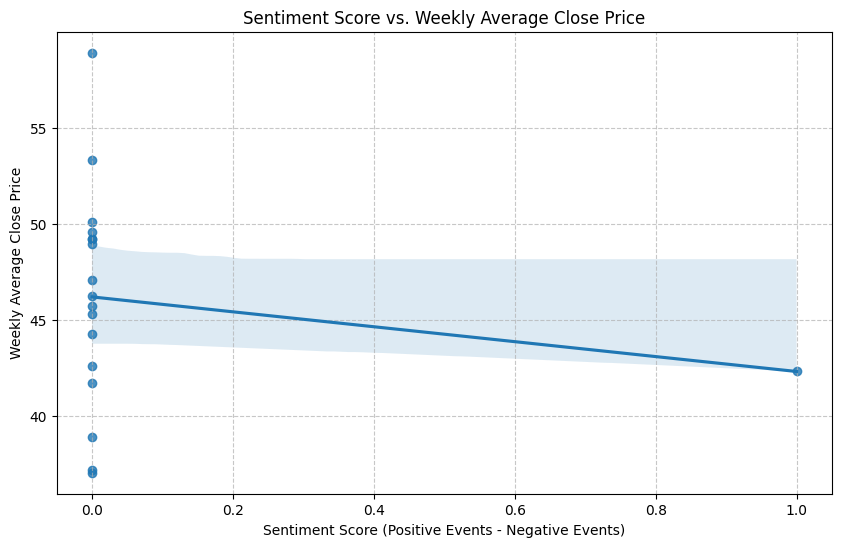

In [ ]:
# Calculate the correlation between 'Sentiment Score' and 'Weekly Avg Close Price'
correlation = final_output_with_price['Sentiment Score'].corr(final_output_with_price['Weekly Avg Close Price'])

print(f"Correlation between Sentiment Score and Weekly Average Close Price: {correlation:.2f}")

# Visualize the correlation using a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Sentiment Score', y='Weekly Avg Close Price', data=final_output_with_price)
plt.title('Sentiment Score vs. Weekly Average Close Price')
plt.xlabel('Sentiment Score (Positive Events - Negative Events)')
plt.ylabel('Weekly Average Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## **Conclusions and Recommendations**

**Conclusions:**

- Event Extraction and Categorization: The model successfully processed weekly news articles and categorized key events into 'Positive Events' and 'Negative Events' as structured lists. This demonstrates the effectiveness of the LLM in understanding and segmenting news sentiment.
- Sentiment Trend Visualization: The weekly sentiment score has been successfully visualized, showing trends, peaks, and troughs in market sentiment derived from news events over time.
- Correlation with Stock Price: A correlation analysis between the 'Sentiment Score' and 'Weekly Average Close Price' yielded a coefficient of -0.16, indicating a very weak negative linear relationship. This suggests that while there is a slight tendency for stock prices to decrease as sentiment improves, the relationship is not strong.
- Initial Sentiment Score: For the initial weeks shown, the 'Sentiment Score' is zero. This indicates that the number of identified positive events is equal to the number of negative events for those specific weeks. This could mean a balanced news week, or that the model found an equal number of influential events on both sides.

**Recommendations:**

- Qualitative Analysis of Events: While we have lists of positive and negative events, a deeper dive into the content of these events (beyond just their count) would provide richer insights. For instance, understanding why certain events are deemed positive or negative and their potential magnitude of impact.
- Refine Event Significance: Currently, each event contributes equally to the sentiment score. Future work could involve assigning weights or impact scores to events based on their perceived significance to provide a more nuanced sentiment analysis.
- Explore Other Correlations: Investigate correlations with other financial indicators or market segments.

<font size=6 color='blue'>Power Ahead</font>
___